# 📊 Data Science with Python Internship

## Task 3: Mini Exploratory Data Analysis (EDA) on Titanic Dataset

### Submitted By:
**Name:** Rahul Chopra

---

## Objective

The objective of this task is to perform Exploratory Data Analysis (EDA) on the Titanic dataset. This analysis focuses on cleaning the data, handling missing values, performing group-based analysis, and creating meaningful visualizations to understand the survival patterns of passengers.

Exploratory Data Analysis helps in understanding the dataset before applying machine learning algorithms and is one of the most important steps in Data Science.

# Step 1: Import Required Libraries

Before starting the analysis, we need to import the required Python libraries.

### Libraries Used

- **Pandas** → Used for data loading and data manipulation.
- **Matplotlib** → Used for creating charts and graphs.
- **Seaborn** → Used for attractive statistical visualizations.

In [3]:
# Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style
sns.set(style="whitegrid")

# Step 2: Load the Dataset

In this step, we load the Titanic dataset into a Pandas DataFrame.

After loading the dataset, we display the first five rows to verify that the dataset has been imported correctly.

In [4]:
# Load Titanic Dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Display first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Step 3: Explore the Dataset

Understanding the structure of the dataset is an important step before analysis.

In this section we will:

- Check the number of rows and columns.
- Display all column names.
- View information about data types.
- Understand the overall structure of the dataset.

In [5]:
# Dataset Shape
print("Dataset Shape:")
print(df.shape)

print("\n")

# Column Names
print("Column Names:")
print(df.columns)

print("\n")

# Dataset Information
print("Dataset Information:")
df.info()

Dataset Shape:
(891, 12)


Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Step 4: Check Missing Values

Real-world datasets often contain missing values.

Before performing analysis, we identify the missing values present in each column.

Handling missing values improves the quality and accuracy of analysis.

In [6]:
# Check Missing Values

print("Missing Values in Dataset")

df.isnull().sum()

Missing Values in Dataset


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Step 5: Data Cleaning

Data cleaning is an essential part of Exploratory Data Analysis.

In this step we perform the following operations:

- Fill missing values in the Age column using the mean age.
- Fill missing values in the Embarked column using the most frequent value (Mode).
- Remove the Cabin column because it contains a large number of missing values.

Finally, we verify that the dataset no longer contains missing values.

In [7]:
# Fill missing Age values with Mean

df["Age"].fillna(df["Age"].mean(), inplace=True)

# Fill missing Embarked values with Mode

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop Cabin Column

df.drop(columns=["Cabin"], inplace=True)

# Check Missing Values Again

print("Missing Values After Cleaning")

df.isnull().sum()

Missing Values After Cleaning


/var/folders/j_/1pttjpxj41105l1lghjw8zlc0000gn/T/ipykernel_51218/3151213642.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/var/folders/j_/1pttjpxj41105l1lghjw8zlc0000gn/T/ipykernel_51218/3151213642.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Step 6: Create Age Groups

Instead of analyzing individual ages, passengers are divided into different age categories.

Age Groups:

- Child (0–12 Years)
- Teen (13–18 Years)
- Young Adult (19–30 Years)
- Adult (31–50 Years)
- Senior (51–80 Years)

This grouping helps us compare survival rates across different age categories.

In [8]:
# Create Age Groups

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,30,50,80],
    labels=["Child","Teen","Young Adult","Adult","Senior"]
)

# Display Age Groups

df[["Age","AgeGroup"]].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult


# Task Question 1

## Analyze Survival Rate by Age Group

The objective of this analysis is to determine whether passengers of different age groups had different chances of survival.

We calculate the average survival rate for each age group using the GroupBy function.

In [9]:
# Survival Rate by Age Group

age_survival = df.groupby("AgeGroup")["Survived"].mean()

print("Survival Rate by Age Group")

print(age_survival)

Survival Rate by Age Group
AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.331096
Adult          0.423237
Senior         0.343750
Name: Survived, dtype: float64


/var/folders/j_/1pttjpxj41105l1lghjw8zlc0000gn/T/ipykernel_51218/1779279196.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby("AgeGroup")["Survived"].mean()


# Visualization 1

## Survival Rate by Age Group

A bar chart is created to visualize survival rates among different age groups.

This visualization helps identify which age category had the highest survival probability.

/var/folders/j_/1pttjpxj41105l1lghjw8zlc0000gn/T/ipykernel_51218/1505033652.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


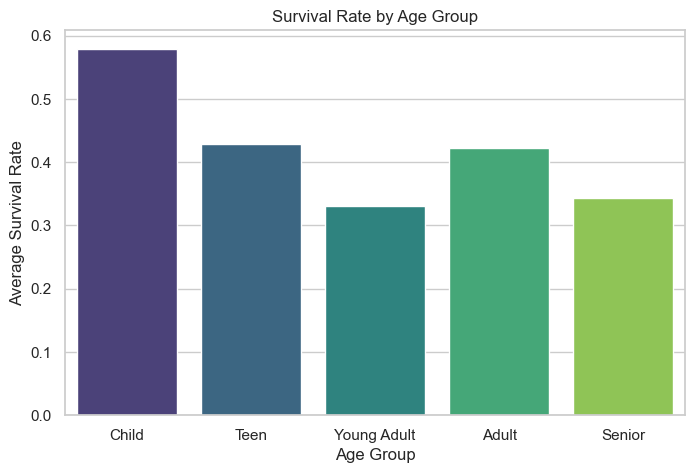

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_survival.index,
    y=age_survival.values,
    palette="viridis"
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Survival Rate")

plt.show()

## Observation

From the visualization, we observe that:

- Young Adults and Adults have relatively higher survival rates.
- Children also show good survival chances.
- Senior passengers have comparatively lower survival rates.

Age appears to have influenced the survival probability during the disaster.

# Task Question 2

## Analyze Survival Rate by Embarkation Port

Passengers boarded the Titanic from three different ports:

- C → Cherbourg
- Q → Queenstown
- S → Southampton

This analysis helps us understand whether the boarding location had any relationship with passenger survival.

In [11]:
# Survival Rate by Embarkation Port

embark_survival = df.groupby("Embarked")["Survived"].mean()

print("Survival Rate by Embarkation Port")

print(embark_survival)

Survival Rate by Embarkation Port
Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


# Visualization 2

## Survival Rate by Embarkation Port

The bar chart compares the average survival rate for passengers embarking from each port.

This visualization highlights the differences among boarding locations.

/var/folders/j_/1pttjpxj41105l1lghjw8zlc0000gn/T/ipykernel_51218/934810437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


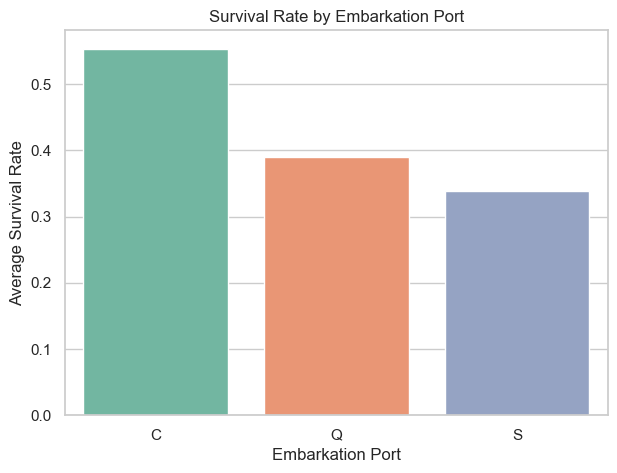

In [12]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=embark_survival.index,
    y=embark_survival.values,
    palette="Set2"
)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Average Survival Rate")

plt.show()

## Observation

From the analysis:

- Passengers from Cherbourg (C) had the highest survival rate.
- Southampton (S) had the largest number of passengers but a comparatively lower survival rate.
- Queenstown (Q) falls between the two.

The embarkation port appears to have some influence on survival outcomes.

# Task Question 3

## Analyze Survival Rate by Family Size

Family Size is calculated using the following formula:

Family Size = SibSp + Parch

Where:

- SibSp = Number of siblings/spouses aboard.
- Parch = Number of parents/children aboard.

This feature helps us understand how family size affected survival.

In [16]:
# Create Family Size

df["FamilySize"] = df["SibSp"] + df["Parch"]

df[["SibSp","Parch","FamilySize"]].head()

# Survival Rate by Family Size

family_survival = df.groupby("FamilySize")["Survived"].mean()

print("Survival Rate by Family Size")

print(family_survival)

Survival Rate by Family Size
FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


# Visualization 3

## Survival Rate by Family Size

A bar plot is created to compare survival rates for passengers travelling with different family sizes.

This helps determine whether travelling alone or with family affected survival.

/var/folders/j_/1pttjpxj41105l1lghjw8zlc0000gn/T/ipykernel_51218/1778596906.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


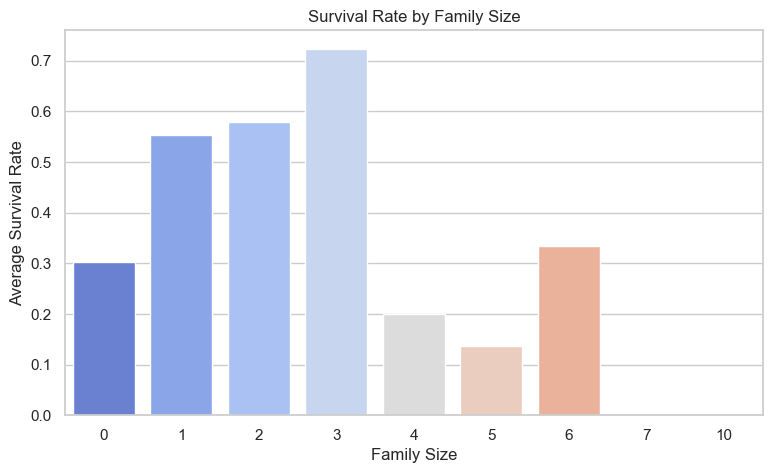

In [17]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values,
    palette="coolwarm"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Average Survival Rate")

plt.show()

## Observation

The analysis shows that:

- Passengers travelling with small families generally had better survival rates.
- Passengers travelling alone had lower survival rates.
- Very large families also experienced lower survival chances.

This indicates that moderate family size may have improved survival opportunities.

# Visualization 4

## Age Distribution

A histogram is created to understand the distribution of passenger ages.

The histogram shows how passengers are distributed across different age ranges and helps identify the most common age group.

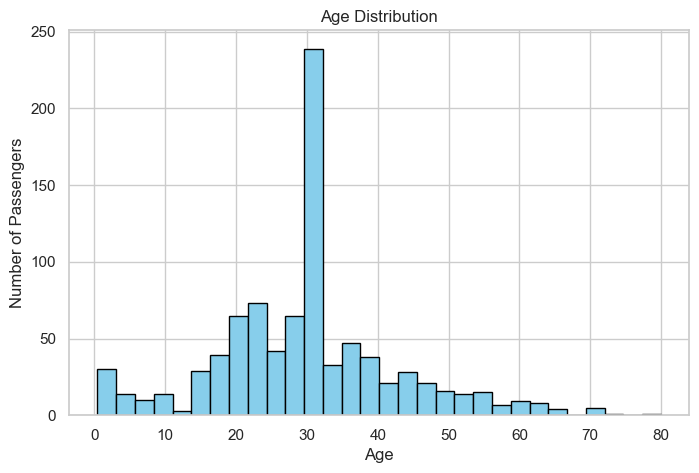

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Observation

The histogram indicates:

- Most passengers were between 20 and 40 years old.
- There were fewer children and senior citizens.
- The age distribution is slightly right-skewed.

This shows that the majority of Titanic passengers were young adults.

# Visualization 5

## Correlation Heatmap

The correlation heatmap shows the relationship between numerical variables in the dataset.

Correlation values range from:

- +1 → Strong Positive Relationship
- 0 → No Relationship
- -1 → Strong Negative Relationship

This visualization helps identify variables that are strongly related.

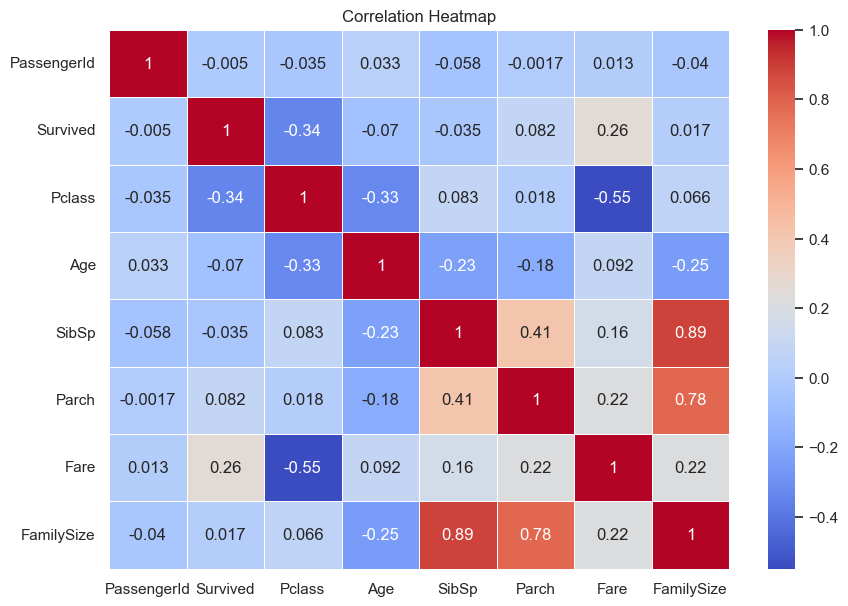

In [19]:
plt.figure(figsize=(10,7))

numeric_df = df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

The heatmap indicates that:

- Fare has a positive correlation with survival.
- Passenger Class (Pclass) has a negative correlation with survival.
- Age has only a weak relationship with survival.
- Family-related features show only mild correlations.

Overall, Passenger Class and Fare appear to influence survival the most.

# Dataset Statistical Summary

The statistical summary provides useful numerical information such as:

- Mean
- Standard Deviation
- Minimum Value
- Maximum Value
- Quartiles (25%, 50%, 75%)

This helps us understand the overall distribution of the numerical variables.

In [20]:
# Statistical Summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.904602
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429,1.613459
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200,0.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,10.000000


# Final Conclusion

## Summary of Task 3

In this Exploratory Data Analysis (EDA), we successfully cleaned and analyzed the Titanic dataset.

### Key Findings

✔ Missing values in the Age column were filled using the mean.

✔ The Cabin column was removed because it contained a large number of missing values.

✔ Passengers were grouped into different age categories for better analysis.

✔ Young Adults and Adults showed comparatively higher survival rates.

✔ Cherbourg passengers had the highest survival rate among all embarkation ports.

✔ Small family groups had better survival chances than passengers travelling alone or in very large families.

✔ Most passengers were between the ages of 20 and 40 years.

✔ The correlation heatmap revealed that Fare positively influenced survival, while Passenger Class showed a negative relationship.

### Conclusion

Exploratory Data Analysis helped us understand important survival patterns in the Titanic dataset using data cleaning, grouping, statistical analysis, and visualizations. These insights provide a strong foundation for future predictive modeling and machine learning applications.